In [18]:
# Imports
import os
import numpy as np
import pandas as pd
import ast
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import matplotlib.animation as animation
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import rcParams
from scipy.fft import fft, ifft, fftfreq
from scipy.signal import butter, filtfilt, find_peaks
from scipy.stats import linregress
from scipy.signal import savgol_filter
from scipy.spatial import KDTree
from scipy.interpolate import interp1d

def read_csv_comments(file):
    # Read the CSV file, skipping comment lines
    metadata = {}
    with open(file, "r") as f:
        lines = f.readlines()
        # Separate comments (metadata) from actual data
        data_lines = []
        for line in lines:
            if line.startswith("#"):
                # Extract metadata from comment lines
                key, value = line[2:].strip().split(":", 1)
                metadata[key] = ast.literal_eval(value.strip())
            else:
                # Collect data lines (non-comment lines)
                data_lines.append(line)

    # Now read the CSV data into a DataFrame from the data lines
    from io import StringIO
    data_str = "".join(data_lines)  # Join the data lines back into a string
    df_read = pd.read_csv(StringIO(data_str))

    # Attach the metadata back to the DataFrame
    df_read.attrs = metadata
    return df_read

In [76]:
video_df = read_csv_comments('/Volumes/Dragonfly3D/Tplax_data/030226/030226_m_250_1_soft_thick_short2_raw.csv')
serial_df = read_csv_comments('/Volumes/Dragonfly3D/Tplax_data/030226/experiment_20260203_174002_m_250_1_soft_thick_short2.csv')


In [77]:
serial_df.head()

,timestamp_s,timestamp_us,node_id,encoder_value,angle_value,motor_command
0,5,569235,2,0,0.53,0.0
1,1770140405,366131,2,0,0.53,0.0
2,1770140405,376129,2,0,0.53,0.0
3,1770140405,386125,2,0,0.53,0.0
4,1770140405,396124,2,0,0.53,0.0


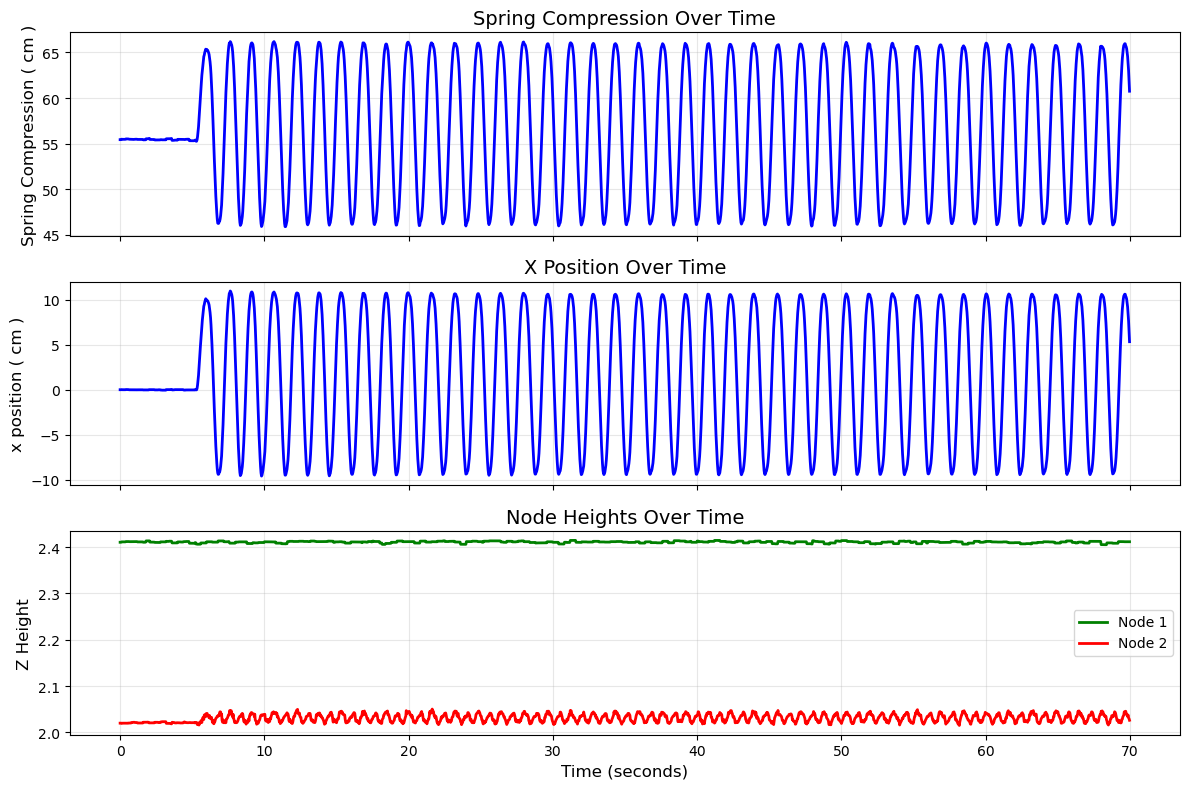

In [78]:
# Extract data for each node by frame
fps = 30
frames = video_df['frame#'].unique()
frames_sorted = np.sort(frames)

# Initialize arrays
time = frames_sorted / fps
spring_compression = []
z_node1 = []
z_node2 = []
xpos = []

# Calculate spring compression and z heights for each frame
for frame in frames_sorted:
    frame_data = video_df[video_df['frame#'] == frame]
    
    # Get positions for each node
    node1_data = frame_data[frame_data['node_id'] == 1]
    node2_data = frame_data[frame_data['node_id'] == 2]
    
    if len(node1_data) > 0 and len(node2_data) > 0:
        # Extract positions
        x1, y1, z1 = node1_data.iloc[0][['x', 'y', 'z']].values
        x2, y2, z2 = node2_data.iloc[0][['x', 'y', 'z']].values
        
        # Calculate spring compression (distance in x/y plane)
        compression = 100. * np.sqrt((x2 - x1)**2 + (y2 - y1)**2) # convert to cm
        spring_compression.append(compression)
        
        # Store z heights
        z_node1.append(z1)
        z_node2.append(z2)
        xpos.append(100*x2)
    else:
        # Handle missing data
        spring_compression.append(np.nan)
        z_node1.append(np.nan)
        z_node2.append(np.nan)
        xpos.append(np.nan)

spring_compression = np.array(spring_compression)
z_node1 = np.array(z_node1)
z_node2 = np.array(z_node2)
xpos = np.array(xpos)
xpos = xpos - xpos[0]

# Create two vertically stacked subplots with shared x-axis
fig, (ax1, ax3,ax2) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Plot 1: Spring compression
ax1.plot(time, spring_compression, linewidth=2, color='blue')
ax1.set_ylabel('Spring Compression ( cm )', fontsize=12)
ax1.set_title('Spring Compression Over Time', fontsize=14)
ax1.grid(True, alpha=0.3)

ax3.plot(time, xpos, linewidth=2, color='blue')
ax3.set_ylabel('x position ( cm )', fontsize=12)
ax3.set_title('X Position Over Time', fontsize=14)
ax3.grid(True, alpha=0.3)

# Plot 2: Z heights
ax2.plot(time, z_node1, label='Node 1', linewidth=2, color='green')
ax2.plot(time, z_node2, label='Node 2', linewidth=2, color='red')
ax2.set_xlabel('Time (seconds)', fontsize=12)
ax2.set_ylabel('Z Height', fontsize=12)
ax2.set_title('Node Heights Over Time', fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Mean time difference between samples: 0.010003 seconds (10.003 ms)
Std time difference between samples: 0.000259 seconds (0.259 ms)


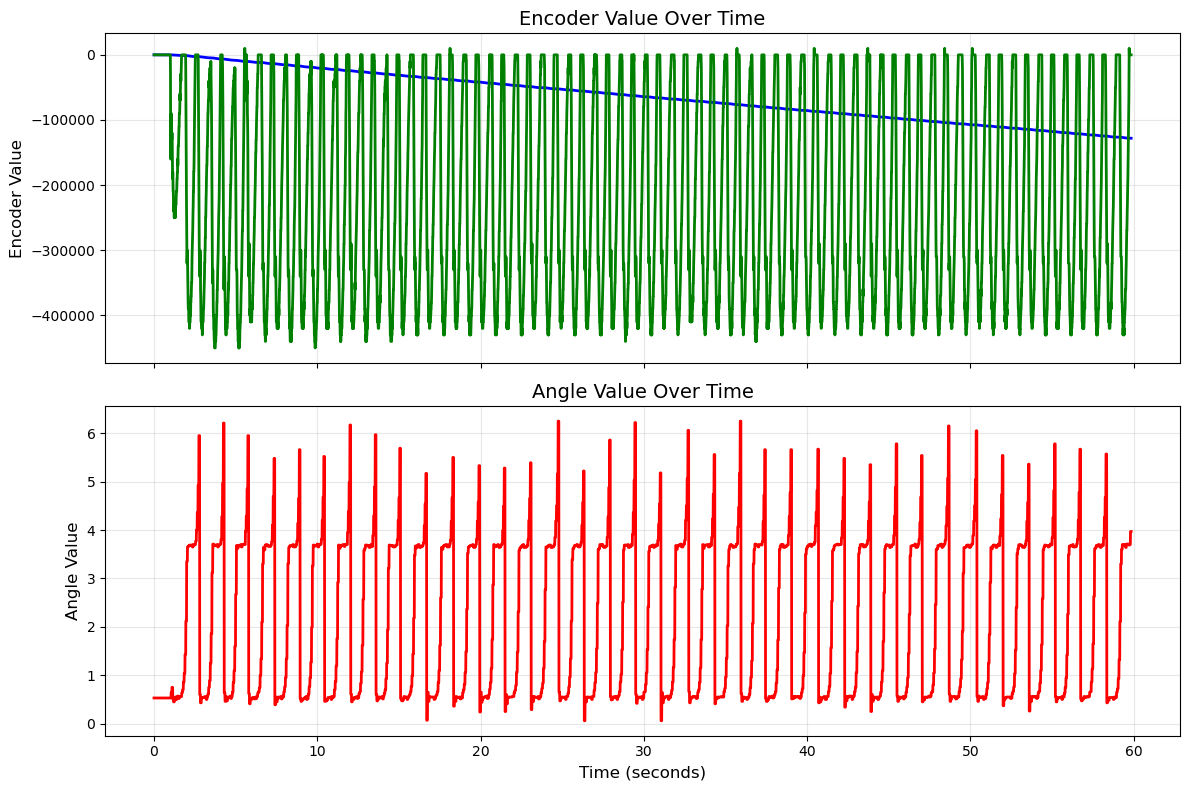

In [92]:
# Process serial_df timestamps
# Convert timestamp (seconds + microseconds) to time array starting at 0
# Find timestamp columns (could be 'timestamp', 'timestamp_s', 'timestamp_us', etc.)
serial_df = serial_df.iloc[1:] # missed some values in first timestamp

cols = serial_df.columns.tolist()



timestamp_total = serial_df['timestamp_s'] + serial_df['timestamp_us'] / 1e6

# Convert to time array starting at 0
time_serial = timestamp_total - timestamp_total.iloc[0]

# Calculate time differences between samples
time_diffs = np.diff(time_serial.values)
mean_dt = np.mean(time_diffs)
std_dt = np.std(time_diffs)

print(f"Mean time difference between samples: {mean_dt:.6f} seconds ({mean_dt*1000:.3f} ms)")
print(f"Std time difference between samples: {std_dt:.6f} seconds ({std_dt*1000:.3f} ms)")

# Extract encoder_value and angle_value
encoder_value = serial_df['encoder_value'].values
encoder_value = encoder_value - encoder_value[0]
angle_value = serial_df['angle_value'].values

# Create two vertically stacked subplots with shared x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot 1: Encoder value
ax1.plot( time_serial, encoder_value, linewidth=2, color='blue')
ax1.plot( time_serial[1:], 10000*np.diff(encoder_value), linewidth=2, color='green')
ax1.set_ylabel('Encoder Value', fontsize=12)
ax1.set_title('Encoder Value Over Time', fontsize=14)
ax1.grid(True, alpha=0.3)

# Plot 2: Angle value
ax2.plot( time_serial, angle_value, linewidth=2, color='red')
ax2.set_xlabel('Time (seconds)', fontsize=12)
ax2.set_ylabel('Angle Value', fontsize=12)
ax2.set_title('Angle Value Over Time', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [98]:
# Synchronize video_df and serial_df datasets
# Find first significant change in encoder_value and xpos, then align them

# Helper function to find first significant change
def find_first_significant_change(values, threshold_std=1.0, min_change=None):
    """
    Find the first index where the value changes significantly from baseline.
    Uses either a threshold based on std or a minimum change value.
    """
    if len(values) < 10:
        return 0
    
    # Calculate baseline (mean of first portion of data)
    baseline_length = min(10, len(values) // 10)
    baseline = np.nanmean(values[:baseline_length])
    baseline_std = np.nanstd(values[:baseline_length])
    
    # Determine threshold
    if min_change is None:
        threshold = threshold_std * baseline_std
    else:
        threshold = min_change
    
    # Find first point where change exceeds threshold
    for i in range(baseline_length, len(values)):
        if not np.isnan(values[i]):
            change = abs(values[i] - baseline)
            if change > threshold:
                return i
    
    return 0  # If no significant change found, return 0

# Find first significant changes
encoder_first_change_idx = find_first_significant_change(encoder_value, threshold_std=2.0, min_change=2)
xpos_first_change_idx = find_first_significant_change(xpos, threshold_std=100.0)

print(f"First significant change in encoder_value at index {encoder_first_change_idx} (time: {time_serial.values[encoder_first_change_idx]:.3f} s)")
print(f"First significant change in xpos at index {xpos_first_change_idx} (time: {time[xpos_first_change_idx]:.3f} s)")

# Calculate time offset to align the two events
time_offset = time_serial.values[encoder_first_change_idx] - time[xpos_first_change_idx]
print(f"Time offset to align events: {time_offset:.3f} s")

# Adjust serial time by the offset
time_serial_aligned = (time_serial - time_offset).values

# Create common time base (use intersection of both time ranges)
time_min = max(time_serial_aligned.min(), time.min())
time_max = min(time_serial_aligned.max(), time.max())
# Use the finer sampling rate (serial data appears to be ~10Hz, video is 30Hz)
# But let's use a reasonable sampling rate that captures both
dt_common = min(1.0/30.0, np.nanmean(np.diff(time_serial_aligned)))  # Use finer of the two
time_common = np.arange(time_min, time_max, dt_common)

print(f"Common time base: {len(time_common)} points from {time_min:.3f} to {time_max:.3f} s (dt={dt_common:.4f} s)")

# Interpolate all data to common time base
# Remove NaN values before interpolation
valid_mask_video = ~(np.isnan(xpos) | np.isnan(spring_compression) | np.isnan(z_node1) | np.isnan(z_node2))
valid_mask_serial = ~(np.isnan(encoder_value) | np.isnan(angle_value))

time_video_valid = time[valid_mask_video]
time_serial_valid = time_serial_aligned[valid_mask_serial]

# Interpolate video data
xpos_interp = interp1d(time_video_valid, xpos[valid_mask_video], 
                       kind='linear', bounds_error=False, fill_value=np.nan)(time_common)
spring_compression_interp = interp1d(time_video_valid, spring_compression[valid_mask_video], 
                                     kind='linear', bounds_error=False, fill_value=np.nan)(time_common)
z_node1_interp = interp1d(time_video_valid, z_node1[valid_mask_video], 
                          kind='linear', bounds_error=False, fill_value=np.nan)(time_common)
z_node2_interp = interp1d(time_video_valid, z_node2[valid_mask_video], 
                          kind='linear', bounds_error=False, fill_value=np.nan)(time_common)

# Interpolate serial data
encoder_value_interp = interp1d(time_serial_valid, encoder_value[valid_mask_serial], 
                                kind='linear', bounds_error=False, fill_value=np.nan)(time_common)
angle_value_interp = interp1d(time_serial_valid, angle_value[valid_mask_serial], 
                              kind='linear', bounds_error=False, fill_value=np.nan)(time_common)

# Create encoder_angle (assuming it's the same as encoder_value, or check if column exists)
if 'encoder_angle' in serial_df.columns:
    encoder_angle = serial_df['encoder_angle'].values
    encoder_angle_interp = interp1d(time_serial_valid, encoder_angle[valid_mask_serial], 
                                     kind='linear', bounds_error=False, fill_value=np.nan)(time_common)
else:
    # Use encoder_value as encoder_angle
    encoder_angle_interp = encoder_value_interp.copy()

print(f"\nInterpolated arrays created (all on common time base 'time_common'):")
print(f"  time_common: {len(time_common)} points")
print(f"  xpos_interp: {len(xpos_interp)} points")
print(f"  spring_compression_interp: {len(spring_compression_interp)} points")
print(f"  z_node1_interp: {len(z_node1_interp)} points")
print(f"  z_node2_interp: {len(z_node2_interp)} points")
print(f"  encoder_angle_interp: {len(encoder_angle_interp)} points")
print(f"  angle_value_interp: {len(angle_value_interp)} points")

First significant change in encoder_value at index 99 (time: 1.010 s)
First significant change in xpos at index 161 (time: 5.367 s)
Time offset to align events: -4.357 s
Common time base: 5982 points from 4.357 to 64.197 s (dt=0.0100 s)

Interpolated arrays created (all on common time base 'time_common'):
  time_common: 5982 points
  xpos_interp: 5982 points
  spring_compression_interp: 5982 points
  z_node1_interp: 5982 points
  z_node2_interp: 5982 points
  encoder_angle_interp: 5982 points
  angle_value_interp: 5982 points


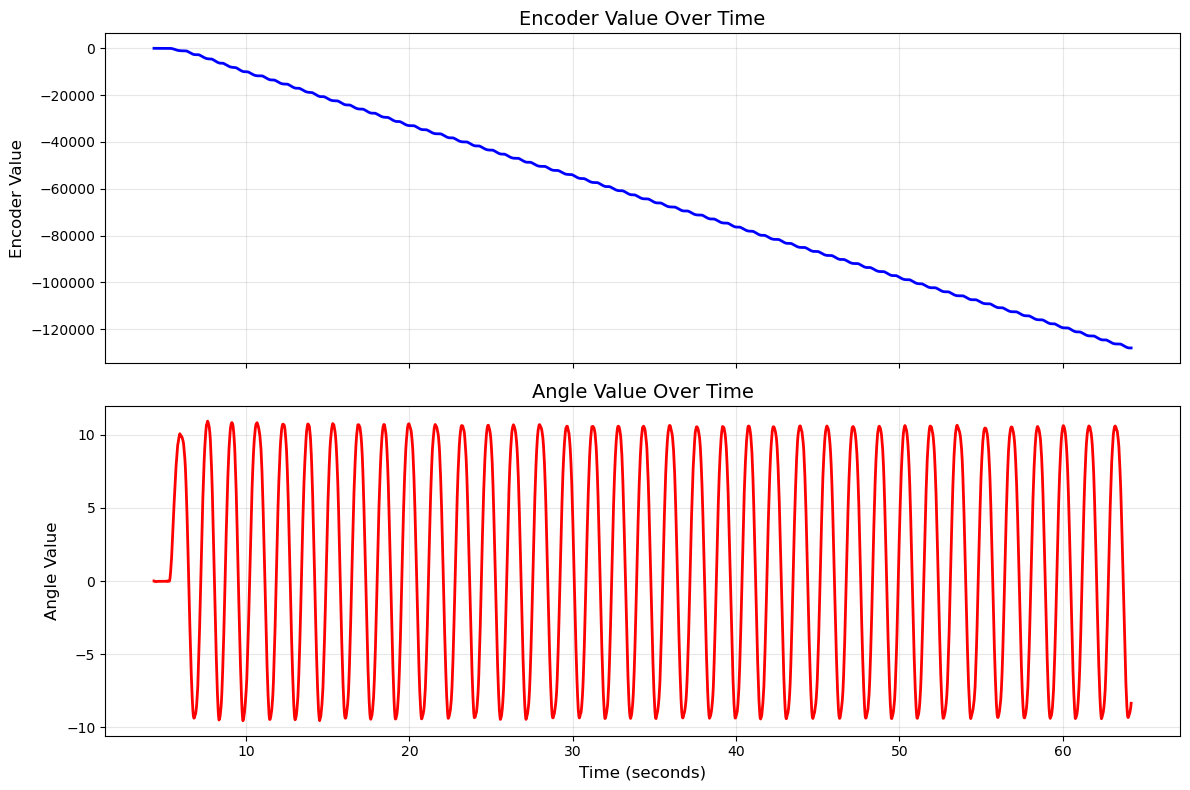

In [99]:
# Create two vertically stacked subplots with shared x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot 1: Encoder value
ax1.plot(time_common, encoder_value_interp, linewidth=2, color='blue')
ax1.set_ylabel('Encoder Value', fontsize=12)
ax1.set_title('Encoder Value Over Time', fontsize=14)
ax1.grid(True, alpha=0.3)

# Plot 2: Angle value
ax2.plot(time_common, xpos_interp, linewidth=2, color='red')
ax2.set_xlabel('Time (seconds)', fontsize=12)
ax2.set_ylabel('Angle Value', fontsize=12)
ax2.set_title('Angle Value Over Time', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

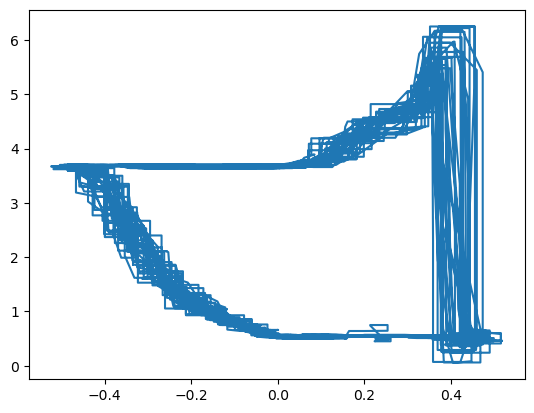

In [101]:
plt.plot(np.diff(xpos_interp),angle_value_interp[1:])

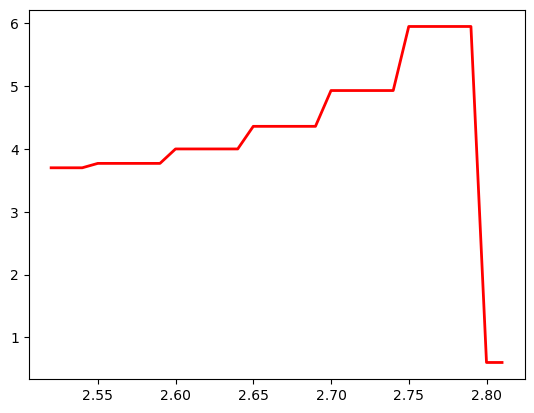

In [96]:
plt.plot(time_serial[250:280], angle_value[250:280], linewidth=2, color='red')

In [97]:
angle_value[250:280]

array([3.7 , 3.7 , 3.7 , 3.77, 3.77, 3.77, 3.77, 3.77, 4.  , 4.  , 4.  ,
       4.  , 4.  , 4.36, 4.36, 4.36, 4.36, 4.36, 4.93, 4.93, 4.93, 4.93,
       4.93, 5.95, 5.95, 5.95, 5.95, 5.95, 0.6 , 0.6 ])

In [40]:
time[173]

np.float64(5.766666666666667)

In [80]:
angle_value

array([0.53, 0.53, 0.53, ..., 3.97, 3.97, 3.97], shape=(5989,))